# Step 6.0 — Sanity Check do Modelo Final (XGBoost tuned, 6 meses)

## 🎯 Objetivo
Validar o ponto de operação (threshold) do modelo final XGBoost:
- o modelo devolve probabilidades `P(rapid)`
- a decisão `rapid/slow` depende do threshold

Neste sanity check:
- comparamos thresholds de referência
- varremos uma grelha para observar trade-off (precision, recall, F2, FP/FN)
- escolhemos um threshold final operacional
- guardamos tabelas/figuras como prova da decisão

## 📥 Inputs
- `01_data/processed/dataset_6m_v1.csv`
- `models/final_xgb_6m.joblib`
- `models/final_xgb_6m_metadata.json`

## 📤 Outputs
- `04_outputs/tables/step6_sanity_xgb_threshold_checks.csv`
- `04_outputs/tables/step6_sanity_xgb_threshold_curve.csv`
- (opcional) `04_outputs/figures/step6_sanity_xgb_f2_vs_threshold.png`

In [1]:
import os, json
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, fbeta_score

DATASET_6M = os.path.join("..", "01_data", "processed", "dataset_6m_v1.csv")
MODEL_PATH = os.path.join("..", "models", "final_xgb_6m.joblib")
META_PATH  = os.path.join("..", "models", "final_xgb_6m_metadata.json")

df = pd.read_csv(DATASET_6M)
pipe = joblib.load(MODEL_PATH)

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

slope_col = meta["slope_col"]
slope_cutoff = meta["slope_cutoff_30pct"]
feat_cols = meta["feature_cols"]

y_true = (df[slope_col] <= slope_cutoff).astype(int).to_numpy()
X = df[feat_cols].copy()

proba = pipe.predict_proba(X)[:, 1]

print("N:", len(df), "| rapid% true:", y_true.mean())
print("slope_cutoff:", slope_cutoff)
print("proba min/mean/max:", float(proba.min()), float(proba.mean()), float(proba.max()))

N: 1392 | rapid% true: 0.30028735632183906
slope_cutoff: -1.2475211387112373
proba min/mean/max: 0.0732557475566864 0.3003116548061371 0.7487792372703552


In [2]:
def eval_at_threshold(y_true, proba, thr, beta=2):
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    return {
        "thr": float(thr),
        "pred_pos_rate": float(y_pred.mean()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "F2": float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
    }

# 3 thresholds de referência:
# - 0.50 (neutro)
# - thr_30pct_pred (para ~30% positivos previstos)
# - thr_from_cv (média do threshold escolhido por fold no Step 5 para XGB tuned)
thr_30pct_pred = float(np.quantile(proba, 1 - 0.30))
thr_from_cv = 0.19  # do teu step5_xgb_tuned_results_6m.csv (thr_decision_mean ≈ 0.19)

checks = [
    eval_at_threshold(y_true, proba, thr_from_cv),
    eval_at_threshold(y_true, proba, 0.50),
    eval_at_threshold(y_true, proba, thr_30pct_pred),
]
checks_df = pd.DataFrame(checks)
checks_df

,thr,pred_pos_rate,TN,FP,FN,TP,precision,recall,F1,F2
0,0.190000,0.795977,252,722,32,386,0.348375,0.923445,0.505898,0.694245
1,0.500000,0.082615,941,33,336,82,0.713043,0.196172,0.307692,0.229435
2,0.351583,0.300287,788,186,186,232,0.555024,0.555024,0.555024,0.555024


In [3]:
ths = np.linspace(0.05, 0.95, 19)
rows = [eval_at_threshold(y_true, proba, t) for t in ths]
curve = pd.DataFrame(rows)[["thr","pred_pos_rate","precision","recall","F2","FP","FN"]]
curve

,thr,pred_pos_rate,precision,recall,F2,FP,FN
0,0.05,1.000000,0.300287,1.000000,0.682115,974,0
1,0.10,0.993534,0.301518,0.997608,0.682488,966,1
2,0.15,0.905172,0.321429,0.968900,0.690655,855,13
3,0.20,0.755747,0.357414,0.899522,0.690162,676,42
4,0.25,0.607040,0.407101,0.822967,0.683353,501,74
5,0.30,0.441810,0.471545,0.693780,0.634018,325,128
6,0.35,0.304598,0.551887,0.559809,0.558206,190,184
7,0.40,0.216236,0.588040,0.423445,0.448555,124,241
8,0.45,0.130029,0.651934,0.282297,0.318403,63,300
9,0.50,0.082615,0.713043,0.196172,0.229435,33,336


In [4]:
OUT_TABLES = os.path.join("..", "04_outputs", "tables")
OUT_FIGS   = os.path.join("..", "04_outputs", "figures")
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGS, exist_ok=True)

checks_path = os.path.join(OUT_TABLES, "step6_sanity_xgb_threshold_checks.csv")
curve_path  = os.path.join(OUT_TABLES, "step6_sanity_xgb_threshold_curve.csv")

checks_df.to_csv(checks_path, index=False)
curve.to_csv(curve_path, index=False)

print("Guardado:", checks_path)
print("Guardado:", curve_path)

Guardado: ..\04_outputs\tables\step6_sanity_xgb_threshold_checks.csv
Guardado: ..\04_outputs\tables\step6_sanity_xgb_threshold_curve.csv


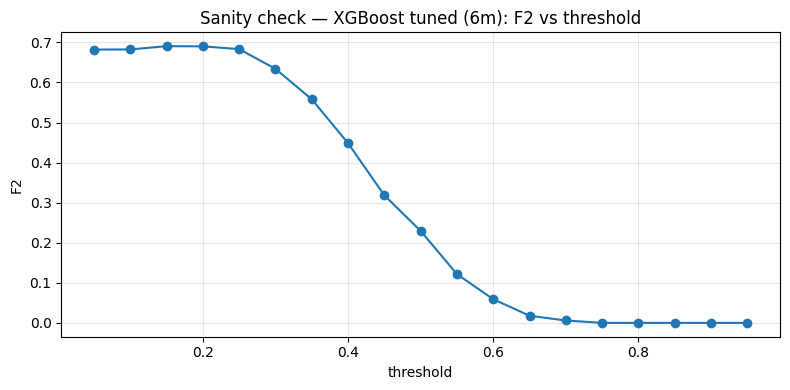

Guardado: ..\04_outputs\figures\step6_sanity_xgb_f2_vs_threshold.png


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(curve["thr"], curve["F2"], marker="o")
plt.xlabel("threshold")
plt.ylabel("F2")
plt.title("Sanity check — XGBoost tuned (6m): F2 vs threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(OUT_FIGS, "step6_sanity_xgb_f2_vs_threshold.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print("Guardado:", fig_path)

In [6]:
import json

META_PATH  = os.path.join("..", "models", "final_xgb_6m_metadata.json")

FINAL_THR = 0.25  

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

meta["decision_threshold_old"] = meta.get("decision_threshold", None)
meta["decision_threshold"] = float(FINAL_THR)
meta["decision_threshold_reason"] = "sanity-check trade-off: chosen to balance recall and operational load"

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Atualizado:", META_PATH)
print("old -> new:", meta["decision_threshold_old"], "->", meta["decision_threshold"])

Atualizado: ..\models\final_xgb_6m_metadata.json
old -> new: None -> 0.25
